Shared imports/ project setup

In [1]:
# Standard Libraries
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools
import warnings

# Scikit-Learn: Datasets
from ucimlrepo import fetch_ucirepo

# Scikit-Learn: Preprocessing, Imputation, & Pipelines
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder

# Scikit-Learn: Model Selection, Evaluation, & Visualization
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.inspection import DecisionBoundaryDisplay

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import NearestCentroid
from sklearn.neural_network import MLPClassifier


In [2]:
#SETUP/ PREPROCESSING

warnings.filterwarnings("ignore")

print("Fetching UCI Diabetes Dataset...")
diabetes = fetch_ucirepo(name='Diabetes 130-US Hospitals for Years 1999-2008') # previously df
X = diabetes.data.features
y = diabetes.data.targets['readmitted']

# Encode target (readmission). 
# readmitted {0: '<30', 1: '>30', 2: 'NO'}
y = y.values.ravel()
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Handle missing data
X = X.replace('?', np.nan) # replace ? with NaN

# Identify column types
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object', 'category']).columns

# preprocess data for use across all models
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_features),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), categorical_features)
    ])

print("Applying Preprocessing Pipeline...")
X_preprocessed = preprocessor.fit_transform(X)

Fetching UCI Diabetes Dataset...
Applying Preprocessing Pipeline...


In [3]:
# create data split based on project overview, section 4 experimental setup

seed = 1234
np.random.seed(seed)

# 60% Test Split
X_temp, X_te, y_temp, y_te = train_test_split(
    X_preprocessed, y_encoded, test_size=0.60, random_state=seed, stratify=y_encoded
)

# Split remaining 40% into 20% Train and 20% Validation
X_tr, X_val, y_tr, y_val = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=seed, stratify=y_temp)

In [4]:
X.head()

,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,...,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed
0,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,...,No,No,No,No,No,No,No,No,No,No
1,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,...,No,No,Up,No,No,No,No,No,Ch,Yes
2,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,...,No,No,No,No,No,No,No,No,No,Yes
3,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,...,No,No,Up,No,No,No,No,No,Ch,Yes
4,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,...,No,No,Steady,No,No,No,No,No,Ch,Yes


In [5]:
#y.head()
y_encoded[:5]

array([2, 1, 2, 2, 2])

Linear Regression

Nearest Centroid

MLP 

In [6]:
# hypertuning params, from hw3

tuning_results = []
mlp_loss_curves = {}

lr_options = [0.001, 0.005]
hidden_options = [(256,), (512,)]
alpha_options = [0.0001, 0.01]
activation_options = ['relu']
batch_options = [32, 64]

combinations = itertools.product(lr_options, hidden_options, alpha_options, activation_options, batch_options)

for lr, hidden, alpha, activation, batch in combinations:
    config = {
        'learning_rate_init' : lr,
        'hidden_layer_sizes' : hidden,
        'alpha' : alpha,
        'activation' : activation,
        'solver' : 'sgd',
        'batch_size' : batch,
        'random_state' : seed,
        # limit our model bc the dataset is larger than hw ds have been
        'max_iter': 50,
        'early_stopping': True, 
        'n_iter_no_change': 5
    }

    mlp = MLPClassifier(**config)
    mlp.fit(X_tr, y_tr)
    print(f"Finished tuning: LR={lr}, Hidden={hidden}, Batch={batch} | Epochs run: {mlp.n_iter_}")
    
    tuning_results.append({
        'config': config, 
        'train_acc': mlp.score(X_tr, y_tr),
        'val_acc': mlp.score(X_val, y_val)
    })

    curve_key = f"lr={lr}, batch={batch}"
    mlp_loss_curves[curve_key] = mlp.loss_curve_


# Identify the best hyperparameters based on validation accuracy
final_hyperparameters = max(tuning_results, key=lambda x: x['val_acc'])['config']
final_hyperparameters['max_iter'] = 100

# Train final model and evaluate on the test set
final_model = MLPClassifier(**final_hyperparameters)
final_test_accuracy = final_model.fit(X_tr, y_tr).score(X_te, y_te)


print('Number of configurations tried:', len(tuning_results))
print('Final hyperparameters:', final_hyperparameters)
print('Final test accuracy:  ', final_test_accuracy)

Finished tuning: LR=0.001, Hidden=(256,), Batch=32 | Epochs run: 21
Finished tuning: LR=0.001, Hidden=(256,), Batch=64 | Epochs run: 24
Finished tuning: LR=0.001, Hidden=(256,), Batch=32 | Epochs run: 21
Finished tuning: LR=0.001, Hidden=(256,), Batch=64 | Epochs run: 18
Finished tuning: LR=0.001, Hidden=(512,), Batch=32 | Epochs run: 22
Finished tuning: LR=0.001, Hidden=(512,), Batch=64 | Epochs run: 37
Finished tuning: LR=0.001, Hidden=(512,), Batch=32 | Epochs run: 25
Finished tuning: LR=0.001, Hidden=(512,), Batch=64 | Epochs run: 37
Finished tuning: LR=0.005, Hidden=(256,), Batch=32 | Epochs run: 15
Finished tuning: LR=0.005, Hidden=(256,), Batch=64 | Epochs run: 15
Finished tuning: LR=0.005, Hidden=(256,), Batch=32 | Epochs run: 13
Finished tuning: LR=0.005, Hidden=(256,), Batch=64 | Epochs run: 15
Finished tuning: LR=0.005, Hidden=(512,), Batch=32 | Epochs run: 10
Finished tuning: LR=0.005, Hidden=(512,), Batch=64 | Epochs run: 15
Finished tuning: LR=0.005, Hidden=(512,), Batch=

In [7]:
# Display results
tuning_table = pd.DataFrame([
    {**r['config'], 'train_acc': r['train_acc'], 'val_acc': r['val_acc']}
    for r in tuning_results
])
tuning_table

,learning_rate_init,hidden_layer_sizes,alpha,activation,solver,batch_size,random_state,max_iter,early_stopping,n_iter_no_change,train_acc,val_acc
0,0.001,"(256,)",0.0001,relu,sgd,32,1234,50,True,5,0.601975,0.579521
1,0.001,"(256,)",0.0001,relu,sgd,64,1234,50,True,5,0.593966,0.579964
2,0.001,"(256,)",0.0100,relu,sgd,32,1234,50,True,5,0.601386,0.579325
3,0.001,"(256,)",0.0100,relu,sgd,64,1234,50,True,5,0.583059,0.576819
4,0.001,"(512,)",0.0001,relu,sgd,32,1234,50,True,5,0.601582,0.581536
5,0.001,"(512,)",0.0001,relu,sgd,64,1234,50,True,5,0.603597,0.580946
6,0.001,"(512,)",0.0100,relu,sgd,32,1234,50,True,5,0.604677,0.581536
7,0.001,"(512,)",0.0100,relu,sgd,64,1234,50,True,5,0.603400,0.580652
8,0.005,"(256,)",0.0001,relu,sgd,32,1234,50,True,5,0.601975,0.576770
9,0.005,"(256,)",0.0001,relu,sgd,64,1234,50,True,5,0.599175,0.578981


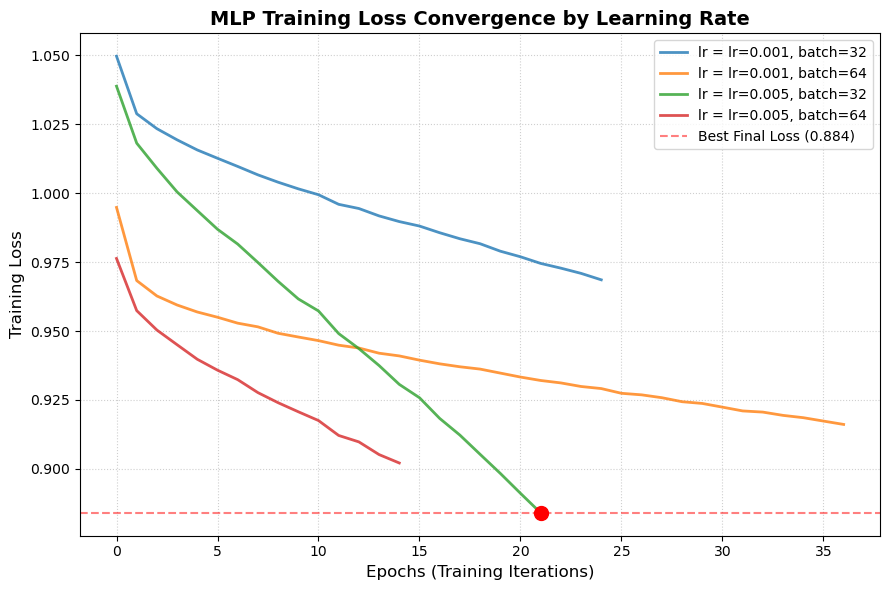

In [8]:
# Learning Loss Convergence
fig, ax = plt.subplots(figsize=(9, 6))

# Track the absolute best loss to highlight it
best_loss = float('inf')
best_lr = None
best_epoch = 0

for lr, loss_history in mlp_loss_curves.items():
    # Plot each line
    line, = ax.plot(loss_history, label=f'lr = {lr}', linewidth=2, alpha=0.8)
    
    # Check if this is the lowest loss we've seen
    if loss_history[-1] < best_loss:
        best_loss = loss_history[-1]
        best_lr = lr
        best_epoch = len(loss_history) - 1

# Dashed line marking the lowest loss achieved
ax.axhline(y=best_loss, color='red', linestyle='--', alpha=0.5, 
           label=f'Best Final Loss ({best_loss:.3f})')

# Highly visible dot exactly where the best model finished
ax.scatter(best_epoch, best_loss, color='red', s=100, zorder=5)

# Lables
ax.set_title('MLP Training Loss Convergence by Learning Rate', fontsize=14, fontweight='bold')
ax.set_xlabel('Epochs (Training Iterations)', fontsize=12)
ax.set_ylabel('Training Loss', fontsize=12)
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

Logistic Classifiers

Beata Strack, Jonathan P. DeShazo, Chris Gennings, Juan L. Olmo, Sebastian Ventura, Krzysztof J. Cios, and John N. Clore, “Impact of HbA1c Measurement on Hospital Readmission Rates: Analysis of 70,000 Clinical Database Patient Records,” BioMed Research International, vol. 2014, Article ID 781670, 11 pages, 2014.